# 리포트 8-4 — 마이크로도플러: 무엇을 잴 수 있나

> **8 권은 다섯 편이다** — [08_1 시나리오](08_1_scene.ipynb) · [08_2 세 엔진과 거리](08_2_engines.ipynb) · [08_3 무늬를 정하는 것](08_3_pattern.ipynb) · [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb) · [08_5 바이스태틱](08_5_bistatic.ipynb)

> **두 가지가 잴 수 있는 것을 제한한다 — 광선 비용과 조명원 반복률.** 앞의 것은 우리가 감당하는 문제이고, 뒤의 것은 우리가 못 정하는 조건이다.

⭐ 본문 숫자는 계산 결과 JSON(원장)에서 주입된다 — 원장이 다시 계산되면 `python src/make_report08_microdoppler.py` 한 번으로 본문 숫자가 따라 바뀐다. 원장이 없는 자리는 «원장 없음» 이라고 적고 그 숫자를 비율·헤드라인에서 뺀다.


## 거리 — 벽인가 예산인가

**시나리오** — 진짜 모노스태틱(TX=RX, 기선 0), 배 쪽(방위 0·앙각 −15), 3.5 GHz CW. 표적을 3 → 10 → 20 → 40 m 로 물리며 자세당 발견 경로 수를 셌다.

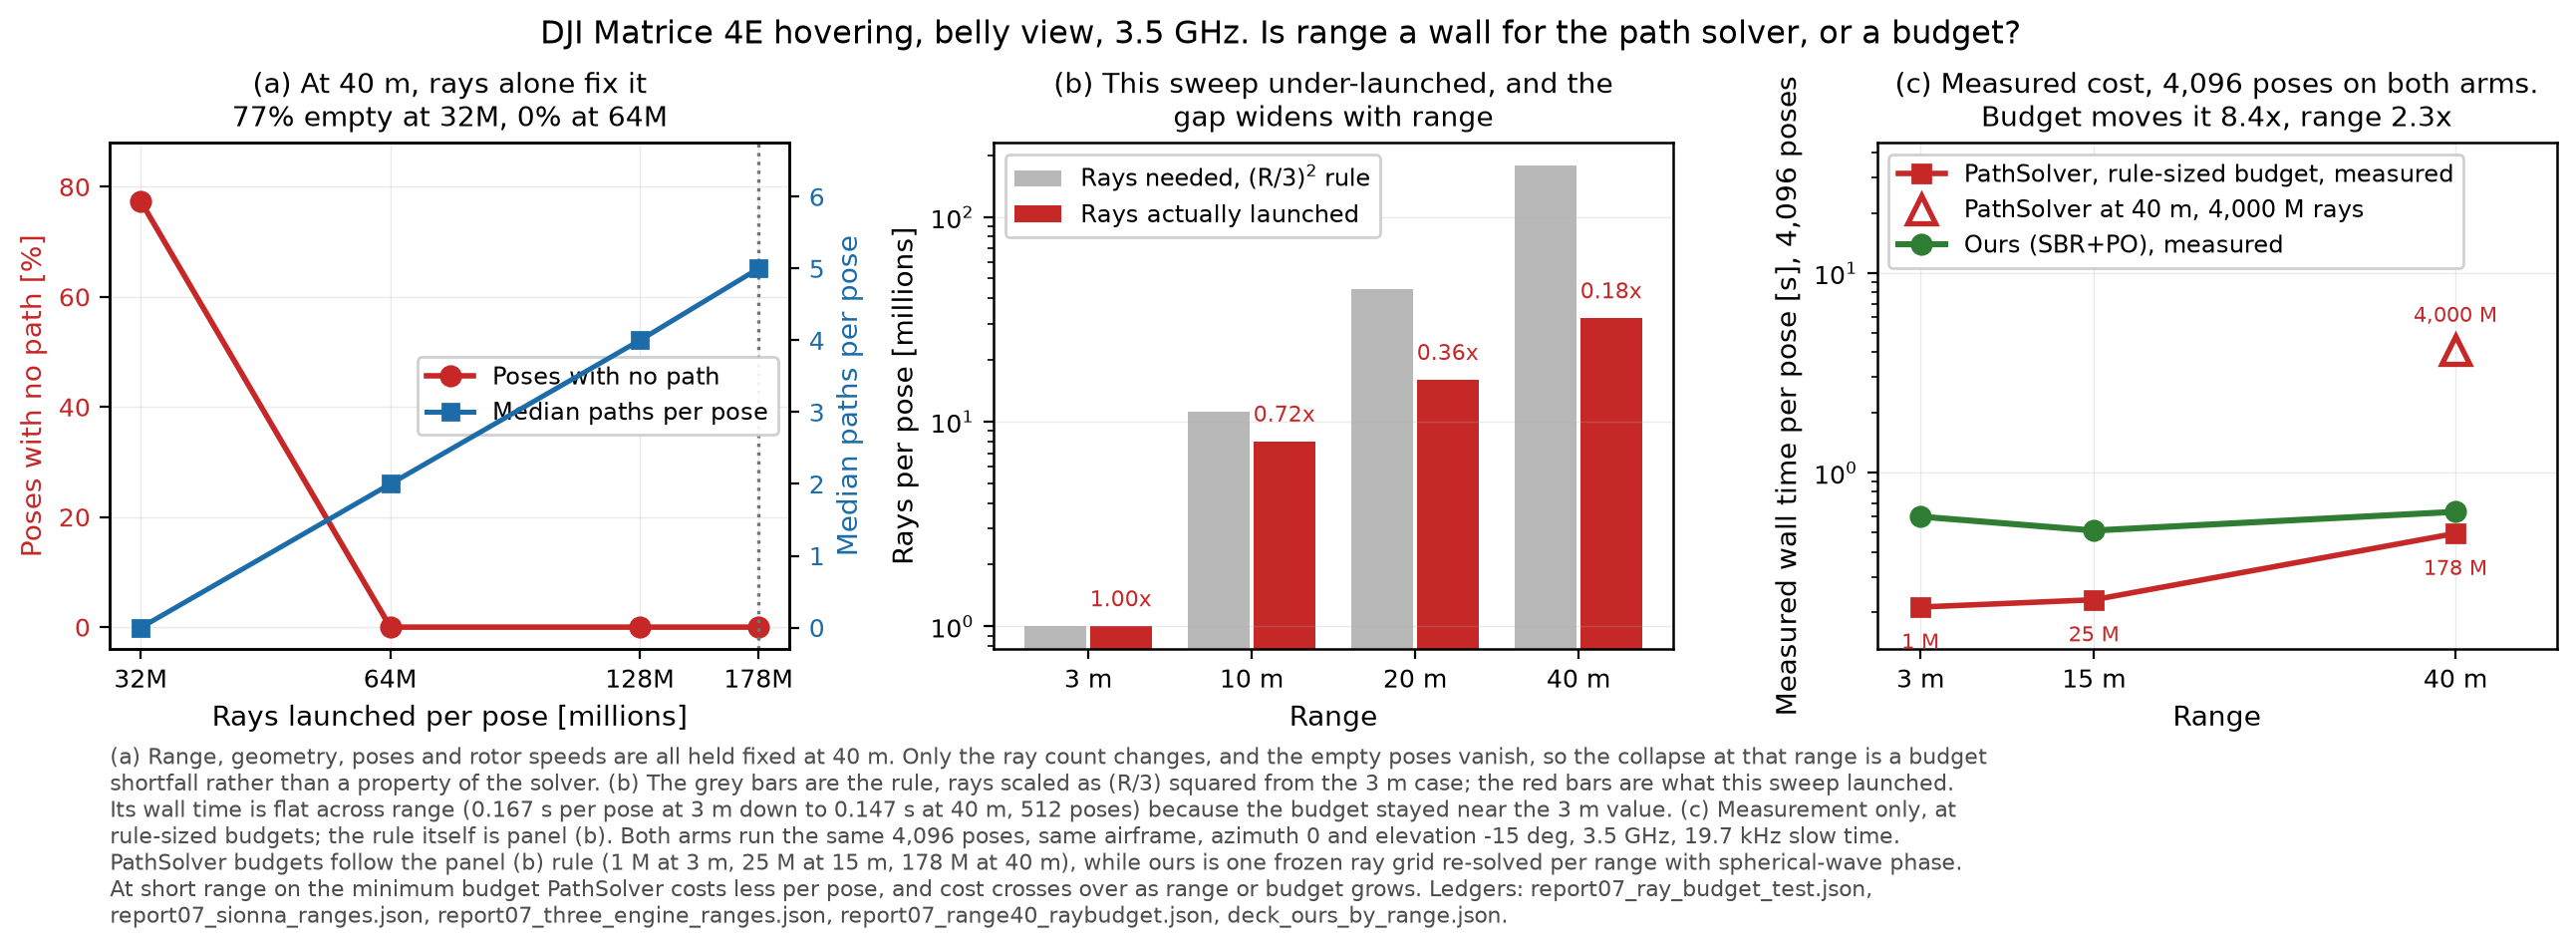

⚠ **이 스윕이 쓴 광선 예산은 규칙값보다 적다 — 그것을 먼저 적는다.** 표적이 멀어지면 그만큼 작게 보이므로 광선을 (R/3)² 로 늘리는 것이 이 프로젝트의 규칙인데(원장 `_meta.spp_scaling_ko`), 이 스윕이 실제로 준 것은 규칙값의 **1.00** / **0.72** / **0.36** / **0.18** 배다 (3 m / 10 m / 20 m / 40 m). 그래서 40 m 에서 자세의 78.3% 가 경로 0 인 것은 **거리의 성질이 아니라 그 예산의 성질**이다.

⭐ 그 둘을 가르려고 **결판 시험**을 했다 — 40 m 를 고정하고 자세·기하·회전수를 그대로 둔 채 **광선만** 사다리로 올렸다.

| 40 m 광선 | 경로 중앙 | 경로 평균 | 빈 자세 (자세 128 개 중) |
|---|---|---|---|
| 32M | 0 | 0.34 | 77.3% |
| 64M | 2 | 1.66 | 0.0% |
| 128M | 4 | 3.69 | 0.0% |
| 178M | 5 | 5.38 | 0.0% |

⭐ **판정 — 예산 부족이었다 — 광선을 규칙대로 쏘니 빈 자세가 사라진다** 규칙값(178M)의 절반도 안 되는 지점에서 이미 빈 자세가 사라진다.

⭐ **두 판이 서로 맞는다.** 사다리는 자세 128 개 판이고 위 스윕은 자세 512 개 판이다. 같은 32M 발에서 빈 자세가 77.3% ↔ 78.3% 로 만난다.

⭐ **그러면 무엇이 남는가 — 비용이다.** 거리가 두 배면 광선을 네 배 부어야 같은 경로 수를 얻는다. 40 m 규칙값이 178M 이면 100 m 에서는 그 6.2 배가 필요하다. 그 규칙은 **광선 수**의 규칙이므로, 비용은 따로 잰다.

⭐ **비용을 두 팔에서 실제로 쟀다** — 아래는 자세당 벽시계 초다. 세 원장이 같은 판이라 바로 견줄 수 있다(matrice4e · 방위 0 · 앙각 −15 · 3.5 GHz · 슬로타임 19.7 kHz · 자세 4,096 개). 그림 f9 (c) 가 이 표를 그린다.

| 어느 팔 | 광선 예산 | 3 m | 15 m | 40 m | 원장 |
|---|---|---|---|---|---|
| **S** · Sionna PathSolver | 규칙값 1M / 25M / 178M 발 | 0.211 s | 0.230 s | 0.495 s | `report07_three_engine_ranges` · `report07_range40_raybudget` |
| **S** · Sionna PathSolver | 40 m 에서 4,000M 발 | — | — | 4.14 s (시드 2 판 평균) | `report07_range40_raybudget` |
| **B** · 우리 SBR+PO | 얼린 격자 한 벌 · 위상만 구면파 | 0.601 s | 0.512 s | 0.635 s | `deck_ours_by_range` |

⭐ **정본 서술** — 가까운 거리에서 최소 예산이면 PathSolver 가 싸고, 멀어지거나 예산을 올리면 우리 커널이 싸다. 40 m 에서 광선을 22.5 배 올리면 자세당 초가 8.4 배로 뛴다 — 자세 4,096 개를 쌓으면 한 판이 4.7 시간이다. 우리 팔은 3 → 40 m 를 0.512~0.635 s 폭 안에서 돈다.

⚠ **거리축을 다시 푼 팔을 밝힌다.** 이 절의 스윕과 08_2 의 거리 표에서 세 거리를 다시 푼 광선 팔은 **PathSolver 하나**다 — `report07_three_engine_ranges.json` 의 `_meta.grid_note_ko` 가 sbr·po 열을 3 m 원장에서 그대로 옮긴다고 적는다. 우리 팔의 거리 비용은 `deck_ours_by_range.json` 이 따로 잰 값이고, 위 표 셋째 행이 그것이다.

⭐ **무늬 쪽은 구조로 선다.** 우리 SBR+PO 는 광선 격자를 **표적에 앵커**(λ/12 간격)한 평면파 조명이라 격자의 크기와 칸수를 표적이 정한다. 원거리장 경계(8.26 m · D = 수평 최대치수 · 3D 대각으로 잡으면 14.1 m · 출처 `report15_probe.json`) 밖에서는 무늬가 거리에 **불변**이고 수신 레벨만 1/R² 로 내려간다. ⚠ 같은 2D²/λ 를 이 스윕 원장은 D 를 조금 달리 잡아 8.04 m 로 적는다 — 이 편은 앞의 한 값으로 쓴다.

⭐ 그러므로 원거리 마이크로도플러에서 팔을 고르는 잣대는 **예산**이다 — 40 m 규칙 예산에서 PathSolver 는 자세당 0.495 s 로 우리 팔(0.635 s) 아래에 있고, 같은 거리에서 예산을 22.5 배로 올리면 4.14 s 로 우리 팔의 6.5 배가 된다.


## 같은 채널에 5G 파형을 실제로 태우면

**시나리오** — 채널은 08_3 의 2 초 호버링 h(t) 이고, 이 절이 쓰는 열은 그 원장의 **얼기 전 판**이다 — `outputs/prefreeze/report07_hover_long.npz::E` 와 바이트 동일하다(5G 원장 2026-08-10 15:11). 바꾼 것은 파형뿐이다: 5G NR 형 OFDM — SCS 30 kHz(n78) · 유효 부반송파 1,024개 · 심볼마다 무작위 QPSK · 심볼율 28k sym/s. 수신은 기지 심볼 나눗셈으로 심볼마다 채널 ĥ 을 꺼낸다. **네 갈래**는 «채널을 얼마나 자주 읽나»(반복률)만 다르다 — 여기서 «갈래» 는 표본율이고, 8 권의 다른 곳이 쓰는 «팔»(엔진)과 다른 축이다.

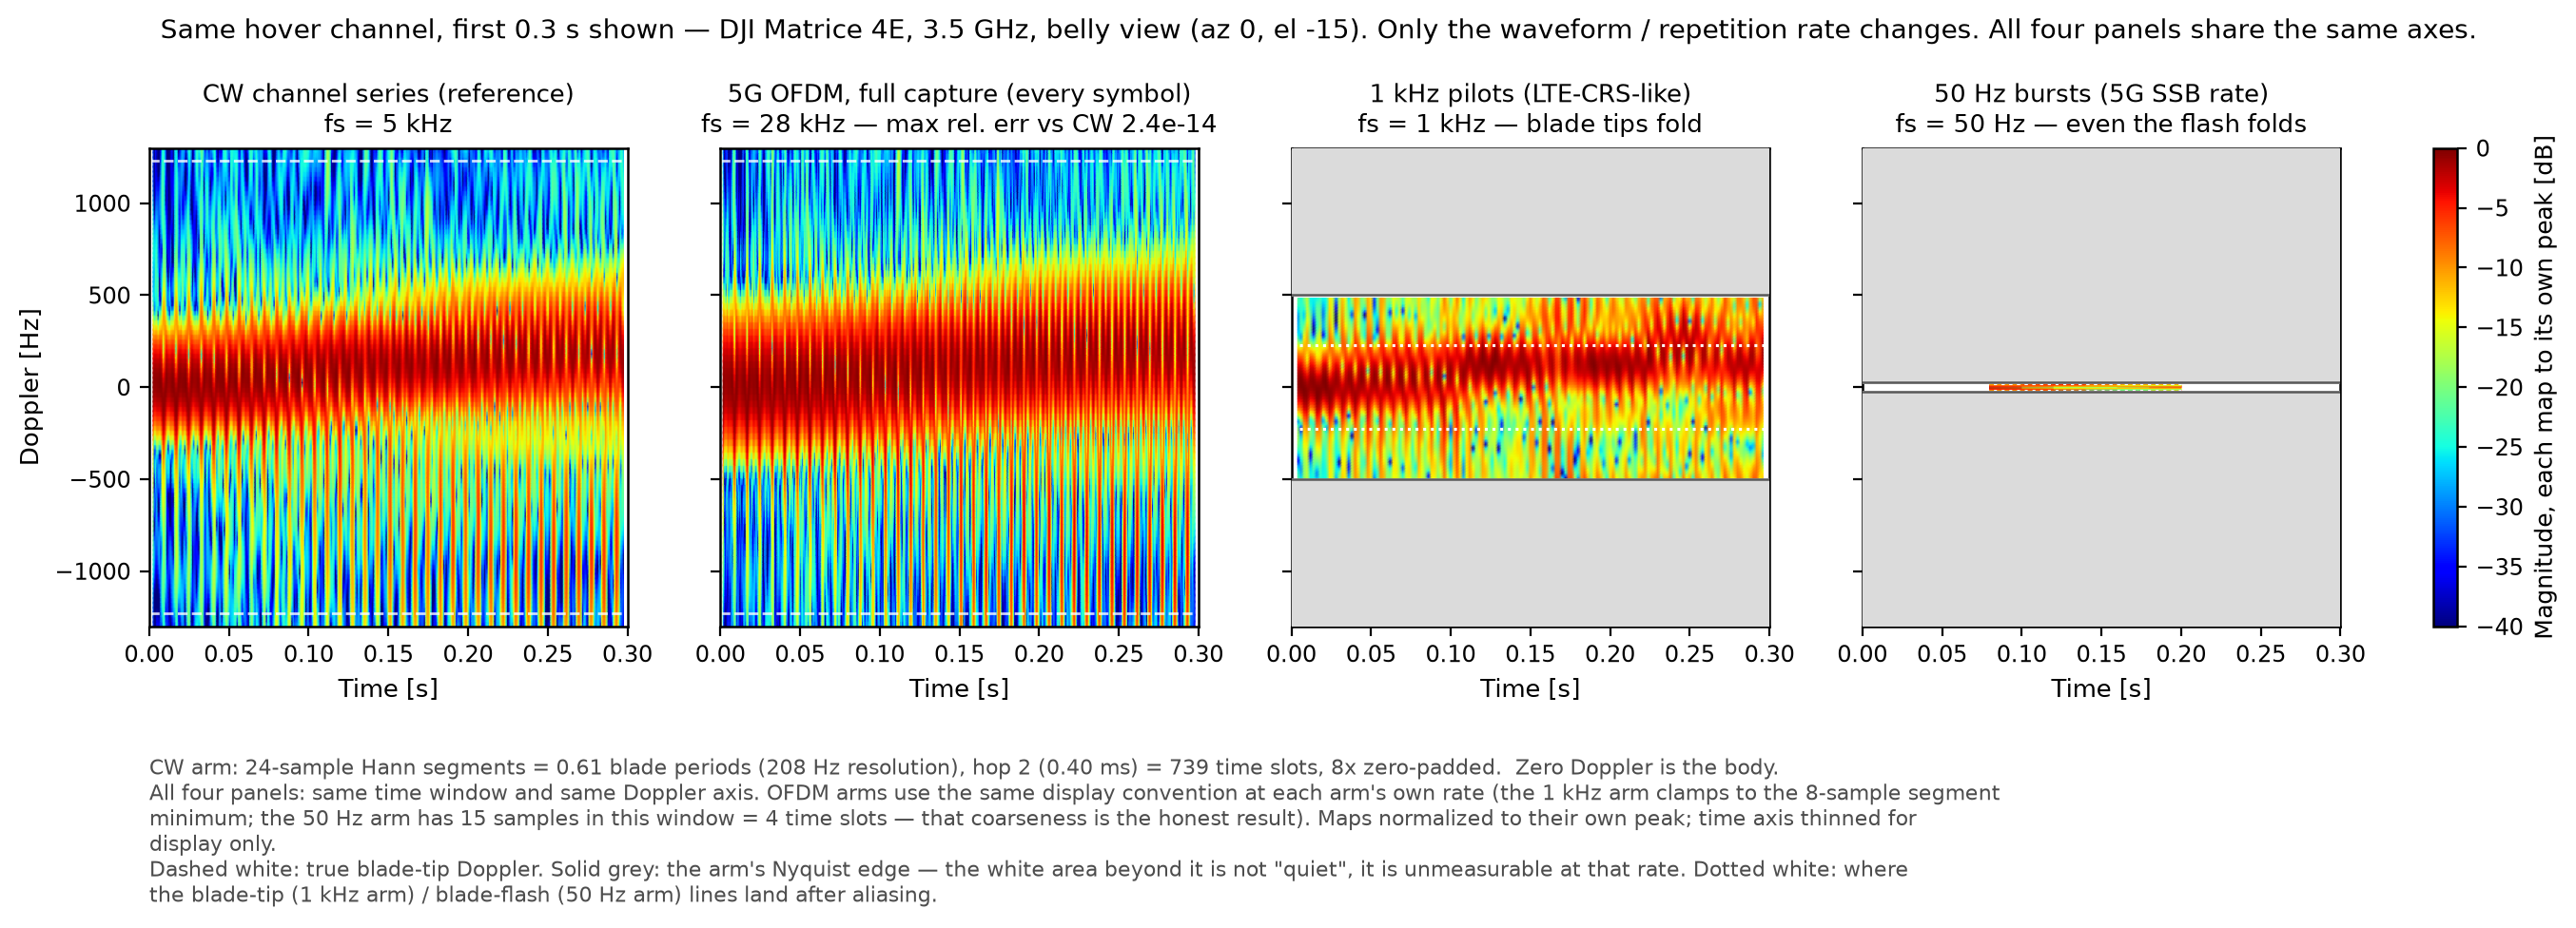

| 갈래 | 표본율 | 나이퀴스트 | 날개끝 ±1229 Hz | 플래시 127 Hz |
|---|---|---|---|---|
| CW channel series (reference) | 19700 Hz | ±9850 Hz | 보임 | 보임 |
| 5G OFDM, full capture (every symbol) | 28000 Hz | ±14000 Hz | 보임 | 보임 |
| 1 kHz pilots (LTE-CRS-like) | 1000 Hz | ±500 Hz | ⚠접힘 | 보임 |
| 50 Hz bursts (5G SSB rate) | 50 Hz | ±25 Hz | ⚠접힘 | ⚠접힘 |

⭐ 이것이 **5G 이중고**의 그림판이다 — 패시브가 기댈 상시 신호 기준으로, LTE CRS 급 1000 Hz 는 날개끝이 나이퀴스트 500 Hz 안으로 **접혀** 들어오고, 5G SSB 급 50 Hz 는 **플래시선마저** 접힌다. 관측 창이 ±25 Hz, 속도로는 ±1.07 m/s 뿐인데 날개끝은 초당 52.6 m 로 움직인다(모노스태틱 환산 v = f·λ/2, λ = 85.7 mm).

⭐ **네 패널은 축이 완전히 같다.** 그래서 낮은 반복률의 대가가 **빈 자리**로 보인다 — 회색으로 덮은 영역은 «조용함» 이 아니라 **그 표본율로는 측정 자체가 불가능한 영역**이다.

⚠ **이 수치가 무엇을 재는지 정확히 적는다.** «풀캡처 ≡ CW» 의 2.6e-14 는 **OFDM 수신 사슬이 채널을 정확히 되돌려주는가**를 잰 것이다. 평탄-채널 근사 아래에서 그 사슬은 항등식이므로 이 값이 작은 것은 **구현이 맞다는 확인**이지, 5G 와 CW 가 같은 물리를 본다는 **독립 검증이 아니다**. ⭐이 그림의 진짜 내용은 오른쪽 두 갈래, 즉 **반복률**에 있다.

⚠ 정직 한계 둘 — 채널열을 심볼율로 다상 보간했고(대역제한 가드 1.2e-03), 심볼 안에서 채널이 도는 ICI 를 1차 근사로 재면 바닥이 -17.8 dB 인데 채널 모형에는 넣지 않았다.

⏳ **이 절의 원장은 재계산 대기다 — 표의 수치를 지금 인용하지 마라.** 채널 원장(`report07_hover_long`)의 PRF 는 19700 Hz 인데 파형 스크립트의 보간 비는 «5 kHz → 심볼율» 에 고정돼 있어, 위 표의 **표본율 라벨과 실제 시간축이 어긋난다**(네 갈래의 나이퀴스트도 그 라벨에서 나온 값이다). 이 절의 논지 — «쓸 수 있는 것을 정하는 것은 파형이 아니라 반복률이다» — 는 그대로지만, 숫자는 `benchmark/report07_5g_waveform.py` 의 보간 비를 채널 PRF 에서 읽게 고쳐 다시 계산한 뒤에 인용한다.


## 부록 — 그림별 데이터 이력

그림마다 딛고 선 원장과 그 시점이 다르다. ⭐**원장의 PRF 가 다르면 시간 분해능도 다르다** — 그래서 그림마다 선명도가 갈릴 수 있다. 마지막 칸은 그 원장의 우리 팔이 어떤 **광선 격자**로 풀렸는가다(**절 [«광선 격자를 어디에 매나»](08_2_engines.ipynb)**).

| 그림 | 편 | 원장 | 생성 | PRF | 광선 격자 |
|---|---|---|---|---|---|
| 애니메이션 · f0 · f0c | 08_1 | 렌더(수치 없음) | 2026-08-10 | — | — |
| f12 · f8 | 08_2 | `report07_three_engines.json` | 2026-08-10 23:34 | 19700 Hz | 얼림 (한 변 124 칸) |
| f2 | 08_2 | `report15_verdict.json` | 2026-08-04 | — | 광선 안 씀(순수 PO ↔ Sionna) |
| f1 · f4 | 08_3 | `report15b_microdoppler.json` | 2026-08-10 23:34 | 19700 Hz | 얼림 |
| f3 | 08_3 | 밴드별 변조 깊이(그림 빌더에 박힌 2026-08-07 실측) | 2026-08-07 | — | ⚠자세마다 다시 정의 |
| f7 | 08_3 | `report07_hover_long.json` | 2026-08-10 23:34 | 19700 Hz | 얼림 (한 변 124 칸) |
| f11 | 08_3 | `report07_hover_long_outdoor.json` | 2026-08-10 23:34 | 19700 Hz | 얼림 (한 변 124 칸) |
| f13 | 08_3 | `rotor_log_traces.json` (공개 비행로그) | 2026-08-10 | 로그 원본 | — (측정 로그) |
| f9 (a)(b) | 08_4 | `report07_ray_budget_test.json` + `report07_sionna_ranges.json` | 2026-08-10 09:19 · 2026-08-10 04:31 | 5000 Hz | **S** 팔(광선 격자 무관) |
| f9 (c) | 08_4 | `report07_three_engine_ranges.json` + `report07_range40_raybudget.json` + `deck_ours_by_range.json` | 2026-08-10 20:04 · 뒤의 둘은 시각 미기록 | 19700 Hz | **S** 팔 실측 3 점 + **B** 팔 실측 3 점(얼린 격자) |
| f10 | 08_4 | `report07_5g_waveform.json` | 2026-08-10 15:11 | 갈래마다 다름 | ⚠얼기 전 판 — 채널열이 `prefreeze/report07_hover_long` |

⚠ **f3 과 f10 이 옛 판 위에 있다.** f3 의 밴드별 변조 깊이는 그림 빌더 안에 2026-08-07 실측값으로 박혀 있고, 그 실측은 자세마다 격자를 다시 정의하는 판에서 난 값이다 — 그 그림의 논지(«블레이드는 강한데 동체가 덮는다» · 프롭 채널 ↔ 전체 드론)는 두 채널을 **같은 판**에서 비교한 것이라 서지만, **깊이의 절대 dB 는 인용하지 마라**. f10 의 채널열은 얼기 전 판이라(위 표) **얼린 판을 쓰는 08_3 의 f7 과 다른 열**이다 — 표본율·나이퀴스트의 논지는 서지만, 이 절의 dB 값은 08_3 과 나란히 두지 마라.

**표시 규약**(8-1~8-4 의 맵 공통 · 8-5 도 같은 규약이다) — 조각 = 블레이드 **0.45 주기**(`md_mapstyle.auto_periods` 가 고르는 값 · 조각이 24 표본 아래로 내려가면 0.6 으로 물러난다) · hop 2 · 제로패딩 8 배 · Hann · gouraud · jet · 색역 0~−40 dB · 0 도플러 안 지움 · 도플러축 ±1.9·f_tip. 정본은 `src/md_mapstyle.py` 다. ⚠ 8-5(바이스태틱)만 도플러축을 ±2.1·f_tip 으로 넓혀 자른다 — 그 편의 축척이 β 마다 달라서다.

⚠ 조각 길이 0.45 는 **정의가 하나뿐인 양**으로만 인용한다 — 조각 70 표본 · Δt 3.55 ms · Δf 281 Hz. «플래시 대비가 최대» 라는 표는 독립 재구현에서 재현되지 않아 내렸다.

**재현**

```bash
# 광선 격자 — 기본은 얼림. 0 이면 옛 판(자세마다 다시 정의)이 그대로 나온다.
export SIONNA2_FREEZE_GRID=1
# 원장 재계산(GPU)
PYTHONPATH=src python benchmark/report07_three_engine_maps.py --n 4096   # SIONNA2_MD_PRF_MULT=16
PYTHONPATH=src python benchmark/report07_hover_long.py --sec 2.0
PYTHONPATH=src python benchmark/report15b_microdoppler_recompute.py
PYTHONPATH=src python benchmark/report07_ray_budget_test.py
# f9 (c) 의 자세당 초 — 두 팔을 같은 자세 수로 잰 원장 셋
PYTHONPATH=src python benchmark/report07_three_engine_ranges.py   # S 팔 3 · 15 m
PYTHONPATH=src python benchmark/report07_range40.py               # S 팔 40 m 샤드
PYTHONPATH=src python benchmark/deck_ours_by_range.py --merge     # B 팔 3 · 15 · 40 m
# 파생 원장(계산 없음 — 디스크에서 다시 잰다)
PYTHONPATH=src python benchmark/build_raybudget_40m_fig.py        # 40 m 예산 원장
PYTHONPATH=src python benchmark/ledger_ptp_robust.py
PYTHONPATH=src python benchmark/ledger_outofband_power.py
# 그림
PYTHONPATH=src python benchmark/build_three_engine_fig.py        # f5 + 코사인 판정
PYTHONPATH=src python benchmark/build_three_engine_ranges_fig.py  # f12
PYTHONPATH=src python benchmark/build_flash_zoom.py               # f8
PYTHONPATH=src python benchmark/build_report07_figs.py            # f1~f4
PYTHONPATH=src python benchmark/build_hover_fig.py                # f7
PYTHONPATH=src python benchmark/build_hover_compare_fig.py        # f11
PYTHONPATH=src python benchmark/build_rotor_log_fig.py            # f13
PYTHONPATH=src python benchmark/build_range_sweep_fig.py          # f9
PYTHONPATH=src python benchmark/build_5g_fig.py                   # f10
# 이 빌더가 내는 네 편(08_1~08_4) — 08_5 는 src/make_report07b_bistatic.py
PYTHONPATH=src python src/make_report08_microdoppler.py
```
